In [1]:
import sys

# Cài các gói cần thiết — bỏ qua nếu đã có
!{sys.executable} -m pip install -q \
    pycocotools \
    opencv-python \
    Pillow \
    numpy pandas tqdm matplotlib \
    diffusers transformers accelerate \
    xformers \
    huggingface_hub

print("OK — all packages ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.7 MB/s eta 0:00:00
OK — all packages ready


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Config & Environment Detection
# ─────────────────────────────────────────────
import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def count_images(dir_path: Path) -> int:
    if not dir_path.exists():
        return 0
    return sum(1 for p in dir_path.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


def resolve_data_root() -> tuple[Path, bool]:
    in_kaggle = Path("/kaggle/working").exists()
    if in_kaggle:
        # Theo dataset bạn cung cấp:
        # /kaggle/input/cars_train/cars_train/*.jpg
        # /kaggle/input/cars_test/cars_test/*.jpg
        input_root = Path("/kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset")
        train_dir = input_root / "cars_train" / "cars_train"
        test_dir = input_root / "cars_test" / "cars_test"
        if not train_dir.exists() or not test_dir.exists():
            raise FileNotFoundError(
                "Không tìm thấy 2 thư mục Kaggle mong đợi:\n"
                f"- {train_dir}\n"
                f"- {test_dir}"
            )
        # Trả về /kaggle/input để scanner lấy cả 2 nhánh train/test
        return input_root, True

    cwd = Path.cwd().resolve()
    for p in [cwd, cwd.parent]:
        if (p / "data").exists():
            return p / "data", False
    raise FileNotFoundError("Không tìm thấy thư mục data cạnh notebook/project")


def resolve_input_images_dir(data_root: Path) -> Path:
    # Ưu tiên các vị trí thường gặp theo đúng 3 folder: train/test/car_devkit
    candidates = [
        data_root / "processed" / "train_car_crops_512",
        data_root / "train" / "images",
        data_root / "train" / "imgs",
        data_root / "test" / "images",
        data_root / "test" / "imgs",
        data_root / "train",
        data_root / "test",
    ]
    for c in candidates:
        if c.exists() and count_images(c) > 0:
            return c

    # Fallback: quét toàn bộ data
    for c in [data_root]:
        if count_images(c) > 0:
            return c

    raise FileNotFoundError(
        "Không tìm thấy ảnh nguồn trong data/. "
        "Cần có ít nhất một trong các nhánh: train/images, test/images, hoặc processed/train_car_crops_512"
    )


DATA_ROOT, IN_KAGGLE = resolve_data_root()
if IN_KAGGLE:
    KAGGLE_INPUT_DIRS = [
        Path("/kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/cars_train/cars_train"),
        Path("/kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/cars_test/cars_test"),
    ]
    INPUT_DIRS = KAGGLE_INPUT_DIRS
else:
    INPUT_DIRS = [resolve_input_images_dir(DATA_ROOT)]

# Giữ biến cũ để tương thích các cell phía dưới
INPUT_CROPS_DIR = INPUT_DIRS[0]

# Output paths
if IN_KAGGLE:
    OUTPUT_BASE = Path("/kaggle/working/data_prep_outputs")
elif (DATA_ROOT / "processed").exists():
    OUTPUT_BASE = DATA_ROOT / "processed"
else:
    OUTPUT_BASE = DATA_ROOT / "prep_outputs"

SQ512_DIR      = OUTPUT_BASE / "sq512"
SYNTH_DIR      = OUTPUT_BASE / "synthetic_occ"
GT_DIR         = SYNTH_DIR / "x_gt"
OCC_DIR        = SYNTH_DIR / "x_occ"
MASK_DIR       = SYNTH_DIR / "masks"
SYNTH_META_CSV = OUTPUT_BASE / "metadata_synthetic_occ.csv"

# COCO cache tách riêng để không ảnh hưởng cấu trúc data hiện tại
COCO_CACHE_DIR = OUTPUT_BASE / "coco_cache"
COCO_IMG_DIR   = COCO_CACHE_DIR / "coco_val2017"
COCO_ANN_FILE  = COCO_CACHE_DIR / "annotations" / "instances_val2017.json"

for d in [SQ512_DIR, GT_DIR, OCC_DIR, MASK_DIR, COCO_IMG_DIR, COCO_ANN_FILE.parent]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

TARGET_SIZE = 512
PAD_VALUE = 128
IOU_MIN = 0.15
IOU_MAX = 0.40
MAX_PASTE_TRIES = 8

print(f"Runtime      : {'Kaggle' if IN_KAGGLE else 'Local'}")
print(f"Device       : {DEVICE} | dtype={DTYPE}")
print(f"DATA_ROOT    : {DATA_ROOT}")
print("INPUT_DIRS   :")
for d in INPUT_DIRS:
    print(f"  - {d} ({count_images(d):,} images)")
print(f"Total images : {sum(count_images(d) for d in INPUT_DIRS):,}")
print(f"OUTPUT_BASE  : {OUTPUT_BASE}")
print(f"SQ512_DIR    : {SQ512_DIR}")
print(f"SYNTH_DIR    : {SYNTH_DIR}")

Runtime      : Kaggle
Device       : cuda | dtype=torch.float16
DATA_ROOT    : /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset
INPUT_DIRS   :
  - /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/cars_train/cars_train (8,144 images)
  - /kaggle/input/datasets/eduardo4jesus/stanford-cars-dataset/cars_test/cars_test (8,041 images)
Total images : 16,185
OUTPUT_BASE  : /kaggle/working/data_prep_outputs
SQ512_DIR    : /kaggle/working/data_prep_outputs/sq512
SYNTH_DIR    : /kaggle/working/data_prep_outputs/synthetic_occ


## Task 1 — Square Padding 512×512 (Letterbox)

Resize giữ aspect ratio, pad trung tính (`128`) về `512×512`.  
Input (Kaggle): `/kaggle/input/cars_train/cars_train/*.jpg` và `/kaggle/input/cars_test/cars_test/*.jpg`.  
Output: `sq512/` — ảnh chuẩn hóa sạch làm `x_gt`.

In [3]:
# ─────────────────────────────────────────────
# CELL 4 — Letterbox Resize → sq512/
# ─────────────────────────────────────────────
import cv2
import numpy as np
from tqdm.auto import tqdm


def letterbox(img: np.ndarray, size: int = 512, pad: int = 128) -> np.ndarray:
    """Resize giữ aspect ratio + center-padding về size×size."""
    h, w = img.shape[:2]
    scale  = size / max(h, w)
    new_w  = max(1, int(round(w * scale)))
    new_h  = max(1, int(round(h * scale)))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.full((size, size, 3), pad, dtype=np.uint8)
    x_off  = (size - new_w) // 2
    y_off  = (size - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def collect_images_recursive(src_dir: Path):
    return sorted(p for p in src_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


def run_letterbox_all(src_dirs, dst_dir: Path, size: int = 512, pad: int = 128):
    src_imgs = []
    for src_dir in src_dirs:
        src_imgs.extend(collect_images_recursive(src_dir))

    if not src_imgs:
        raise FileNotFoundError(f"Không tìm thấy ảnh trong các thư mục: {src_dirs}")

    # Loại trùng theo full path
    src_imgs = sorted(set(src_imgs))

    skipped = saved = 0
    for p in tqdm(src_imgs, desc="Letterbox -> sq512"):
        # Prefix theo folder gốc để tránh trùng tên train/test
        parent_tag = p.parent.name
        dst = dst_dir / f"{parent_tag}_{p.stem}.jpg"

        if dst.exists():
            skipped += 1
            continue

        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is None:
            continue

        out = letterbox(img, size=size, pad=pad)
        cv2.imwrite(str(dst), out, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved += 1

    return saved, skipped, len(src_imgs)


saved, skipped, found = run_letterbox_all(INPUT_DIRS, SQ512_DIR, TARGET_SIZE, PAD_VALUE)
print(f"Found images : {found:,}")
print(f"Saved        : {saved:,}")
print(f"Skipped      : {skipped:,} (already existed)")
print(f"Output       : {SQ512_DIR}")

Letterbox -> sq512:   0%|          | 0/16185 [00:00<?, ?it/s]

Found images : 16,185
Saved        : 16,185
Skipped      : 0 (already existed)
Output       : /kaggle/working/data_prep_outputs/sq512


## Task 2 — Synthetic Occlusion Pipeline (COCO Occluder)

**Quy trình:**
1. Tải COCO val2017 annotations + ảnh (hoặc dùng subset nhỏ)
2. Lấy segment mask từ COCO cho các category **không phải xe** (person, truck, bus… làm occluder thực tế)
3. Paste ngẫu nhiên lên xe với IoU (occlusion ratio) trong khoảng **0.15 – 0.40**
4. Lưu bộ `(x_gt, x_occ, M)` và metadata CSV

> **IoU ở đây** = `area(mask ∩ xe_bbox) / area(xe_bbox)` ≈ tỉ lệ xe bị che — không phải IoU giữa 2 bbox.

**Category COCO dùng làm occluder (mặc định):**  
`person, bus, truck, motorcycle, bicycle, traffic light, stop sign`  
→ Phù hợp bối cảnh giao thông của OVD dataset.

In [4]:
# ─────────────────────────────────────────────
# CELL 6 — Tải COCO val2017 (nếu chưa có)
# ─────────────────────────────────────────────
import urllib.request
import zipfile
import shutil

COCO_ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
COCO_IMG_URL = "http://images.cocodataset.org/zips/val2017.zip"   # ~1 GB


def download_and_extract(url: str, dest_dir: Path, zip_name: str):
    zip_path = dest_dir / zip_name
    dest_dir.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print(f"Đang tải {url} ...")
        urllib.request.urlretrieve(url, str(zip_path))
        print(f"Tải xong: {zip_path}")
    else:
        print(f"Zip đã tồn tại: {zip_path}")

    print(f"Giải nén vào {dest_dir} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(str(dest_dir))
    print("Xong!")


# 1) Annotations
if not COCO_ANN_FILE.exists():
    ann_root = COCO_CACHE_DIR / "annotations"
    download_and_extract(COCO_ANN_URL, ann_root, "annotations.zip")

    # File thường nằm ở annotations/annotations/instances_val2017.json
    nested = ann_root / "annotations" / "instances_val2017.json"
    direct = ann_root / "instances_val2017.json"
    if nested.exists() and not direct.exists():
        shutil.move(str(nested), str(direct))
else:
    print(f"Annotation đã có: {COCO_ANN_FILE}")

# 2) Images
coco_imgs = list(COCO_IMG_DIR.glob("*.jpg"))
if len(coco_imgs) < 100:
    download_and_extract(COCO_IMG_URL, COCO_CACHE_DIR, "val2017.zip")
    extracted = COCO_CACHE_DIR / "val2017"
    if extracted.exists() and extracted != COCO_IMG_DIR:
        COCO_IMG_DIR.mkdir(parents=True, exist_ok=True)
        for p in extracted.glob("*.jpg"):
            dst = COCO_IMG_DIR / p.name
            if not dst.exists():
                shutil.move(str(p), str(dst))
else:
    print(f"COCO images đã có: {len(coco_imgs):,} files trong {COCO_IMG_DIR}")

Đang tải http://images.cocodataset.org/annotations/annotations_trainval2017.zip ...
Tải xong: /kaggle/working/data_prep_outputs/coco_cache/annotations/annotations.zip
Giải nén vào /kaggle/working/data_prep_outputs/coco_cache/annotations ...
Xong!
Đang tải http://images.cocodataset.org/zips/val2017.zip ...
Tải xong: /kaggle/working/data_prep_outputs/coco_cache/val2017.zip
Giải nén vào /kaggle/working/data_prep_outputs/coco_cache ...
Xong!


In [5]:
# ─────────────────────────────────────────────
# CELL 7 — Build COCO Occluder Bank
# ─────────────────────────────────────────────
import json
import numpy as np
import cv2
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask_util

# Category COCO phù hợp bối cảnh giao thông (làm occluder thực tế)
OCCLUDER_CATS = {
    "person", "bus", "truck", "motorcycle",
    "bicycle", "traffic light", "stop sign",
}

print(f"Đang load COCO annotations từ: {COCO_ANN_FILE}")
coco_api = COCO(str(COCO_ANN_FILE))

# Lấy cat ids
cat_ids = coco_api.getCatIds(catNms=list(OCCLUDER_CATS))
print(f"Categories được dùng: {len(cat_ids)} — {OCCLUDER_CATS}")

# Lấy tất cả annotation của các category này
ann_ids  = coco_api.getAnnIds(catIds=cat_ids)
anns     = coco_api.loadAnns(ann_ids)
print(f"Tổng annotations COCO làm occluder: {len(anns):,}")


import pycocotools.mask as coco_mask_util

def coco_ann_to_binary_mask(ann: dict, img_h: int, img_w: int) -> np.ndarray:
    """
    Chuyển annotation COCO sang binary mask (H, W) uint8.
    Xử lý đủ 3 format segmentation:
      1. Polygon list       → frPyObjects → merge → decode
      2. RLE compressed     → decode thẳng (counts là string/bytes)
      3. RLE uncompressed   → frUncompressedRLE → decode (counts là list of int)
    """
    seg = ann["segmentation"]

    if isinstance(seg, list):
        # Format 1: Polygon — list of [x1,y1,x2,y2,...]
        rle = coco_mask_util.frPyObjects(seg, img_h, img_w)
        rle = coco_mask_util.merge(rle)

    elif isinstance(seg, dict):
        counts = seg["counts"]

        if isinstance(counts, list):
            # Format 3: RLE uncompressed — counts là list of int
            # Phải convert sang compressed RLE trước khi decode
            rle = coco_mask_util.frPyObjects(seg, img_h, img_w)

        else:
            # Format 2: RLE compressed — counts là string hoặc bytes
            # Đảm bảo counts là bytes (pycocotools yêu cầu bytes, không phải str)
            if isinstance(counts, str):
                seg = {**seg, "counts": counts.encode("utf-8")}
            rle = seg

    else:
        raise ValueError(f"Segmentation format không hỗ trợ: {type(seg)}")

    return coco_mask_util.decode(rle).astype(np.uint8)


def build_occluder_bank(anns: list, coco_img_dir: Path, coco_api: COCO):
    """
    Trả về list dict:
      {
        "mask": np.ndarray H×W uint8,   # binary 0/1
        "bbox": (x, y, w, h),           # trong ảnh gốc COCO
        "img_path": Path,
      }
    Chỉ giữ occluder có area >= 32×32.
    """
    bank = []
    img_cache = {}

    for ann in anns:
        img_id   = ann["image_id"]
        img_info = coco_api.imgs[img_id]
        img_path = coco_img_dir / img_info["file_name"]

        if not img_path.exists():
            continue

        img_h = img_info["height"]
        img_w = img_info["width"]

        mask = coco_ann_to_binary_mask(ann, img_h, img_w)

        # Bỏ qua mask quá nhỏ
        ys, xs = np.where(mask)
        if len(xs) == 0:
            continue
        bw = xs.max() - xs.min()
        bh = ys.max() - ys.min()
        if bw < 32 or bh < 32:
            continue

        bank.append({
            "mask"    : mask,
            "bbox"    : ann["bbox"],         # [x, y, w, h] COCO format
            "img_path": img_path,
            "img_h"   : img_h,
            "img_w"   : img_w,
        })

    return bank


occluder_bank = build_occluder_bank(anns, COCO_IMG_DIR, coco_api)
print(f"Occluder bank size (after size filter): {len(occluder_bank):,}")

Đang load COCO annotations từ: /kaggle/working/data_prep_outputs/coco_cache/annotations/instances_val2017.json
loading annotations into memory...
Done (t=0.54s)
creating index...
index created!
Categories được dùng: 7 — {'bus', 'person', 'bicycle', 'motorcycle', 'truck', 'stop sign', 'traffic light'}
Tổng annotations COCO làm occluder: 13,103
Occluder bank size (after size filter): 7,690


In [6]:
# ─────────────────────────────────────────────
# CELL 8 — Paste Occluder & Sinh (x_gt, x_occ, M)
# ─────────────────────────────────────────────
import pandas as pd
from tqdm.auto import tqdm

# ── Helpers ──────────────────────────────────

def compute_occlusion_ratio(mask_on_target: np.ndarray) -> float:
    """
    Tỉ lệ vùng xe bị che / tổng diện tích xe.
    mask_on_target: binary 0/1, kích thước TARGET_SIZE × TARGET_SIZE.
    Xe chiếm toàn bộ canvas (đã letterbox) nên denominator = TARGET_SIZE².
    """
    denom = TARGET_SIZE * TARGET_SIZE
    return float(mask_on_target.sum()) / denom


def paste_occluder_on_target(
    target_bgr  : np.ndarray,
    occ_entry   : dict,
    iou_min     : float = IOU_MIN,
    iou_max     : float = IOU_MAX,
    max_tries   : int   = MAX_PASTE_TRIES,
    scale_range : tuple = (0.25, 0.65),
):
    """
    Dán 1 COCO occluder lên target (512×512), retry nếu occlusion ratio ngoài khoảng.

    Trả về:
        x_occ   : np.ndarray BGR (512×512×3)
        occ_mask: np.ndarray uint8 (512×512), 0/255
        ratio   : float  — occlusion ratio cuối cùng
        success : bool   — False nếu tất cả lần thử đều out-of-range
    """
    H, W   = target_bgr.shape[:2]

    # Đọc ảnh COCO donor 1 lần
    donor  = cv2.imread(str(occ_entry["img_path"]), cv2.IMREAD_COLOR)
    if donor is None:
        return None, None, 0.0, False

    seg_mask = occ_entry["mask"]                      # H_d × W_d, binary uint8
    ys, xs   = np.where(seg_mask)
    if len(xs) == 0:
        return None, None, 0.0, False

    # Crop tight bounding box của occluder
    y0c, y1c = ys.min(), ys.max() + 1
    x0c, x1c = xs.min(), xs.max() + 1
    crop_img  = donor  [y0c:y1c, x0c:x1c]
    crop_mask = seg_mask[y0c:y1c, x0c:x1c]           # 0/1

    for _ in range(max_tries):
        # Random scale occluder so với target width
        scale_factor = random.uniform(*scale_range)
        new_w = max(16, int(W * scale_factor))
        scale = new_w / max(1, crop_img.shape[1])
        new_h = max(16, int(crop_img.shape[0] * scale))

        r_img  = cv2.resize(crop_img,  (new_w, new_h), interpolation=cv2.INTER_AREA)
        r_mask = cv2.resize(crop_mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

        # Random rotation ±20°
        angle = random.uniform(-20, 20)
        cx, cy = new_w / 2, new_h / 2
        M_rot  = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        r_img  = cv2.warpAffine(r_img,  M_rot, (new_w, new_h),
                                borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        r_mask = cv2.warpAffine(r_mask, M_rot, (new_w, new_h),
                                flags=cv2.INTER_NEAREST,
                                borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        # Random position (cho phép tràn một chút)
        px = random.randint(-new_w // 4, W - new_w // 4)
        py = random.randint(-new_h // 4, H - new_h // 4)

        # Clip vùng paste trong canvas
        src_x0 = max(0, -px);   dst_x0 = max(0, px)
        src_y0 = max(0, -py);   dst_y0 = max(0, py)
        src_x1 = min(new_w, W - px) if px >= 0 else min(new_w, W)
        src_y1 = min(new_h, H - py) if py >= 0 else min(new_h, H)
        dst_x1 = dst_x0 + (src_x1 - src_x0)
        dst_y1 = dst_y0 + (src_y1 - src_y0)

        if dst_x1 <= dst_x0 or dst_y1 <= dst_y0:
            continue

        patch_img  = r_img [src_y0:src_y1, src_x0:src_x1]
        patch_mask = r_mask[src_y0:src_y1, src_x0:src_x1]

        # Kiểm tra occlusion ratio
        canvas_mask = np.zeros((H, W), dtype=np.uint8)
        canvas_mask[dst_y0:dst_y1, dst_x0:dst_x1] = patch_mask
        ratio = compute_occlusion_ratio(canvas_mask)

        if iou_min <= ratio <= iou_max:
            # Áp dụng paste
            x_occ = target_bgr.copy()
            alpha  = patch_mask[:, :, None].astype(np.float32)
            fg     = patch_img.astype(np.float32)
            bg     = x_occ[dst_y0:dst_y1, dst_x0:dst_x1].astype(np.float32)
            blended = alpha * fg + (1 - alpha) * bg
            x_occ[dst_y0:dst_y1, dst_x0:dst_x1] = blended.astype(np.uint8)

            return x_occ, (canvas_mask * 255).astype(np.uint8), ratio, True

    return None, None, 0.0, False


# ── Main loop ────────────────────────────────

def run_synthetic_occlusion(
    sq512_dir   : Path,
    gt_dir      : Path,
    occ_dir     : Path,
    mask_dir    : Path,
    occluder_bank: list,
    max_samples : int = None,    # None = tất cả
):
    img_paths = sorted(p for p in sq512_dir.iterdir()
                       if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    if max_samples:
        img_paths = img_paths[:max_samples]

    if not occluder_bank:
        raise RuntimeError("occluder_bank rỗng — hãy chạy cell build occluder bank trước.")

    rows     = []
    n_ok     = 0
    n_fail   = 0

    for img_path in tqdm(img_paths, desc="Synthetic occlusion"):
        target = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if target is None:
            n_fail += 1
            continue

        # letterbox lại nếu kích thước chưa đúng
        if target.shape[:2] != (TARGET_SIZE, TARGET_SIZE):
            target = letterbox(target, TARGET_SIZE, PAD_VALUE)

        occ_entry = random.choice(occluder_bank)
        x_occ, occ_mask, ratio, ok = paste_occluder_on_target(target, occ_entry)

        if not ok:
            n_fail += 1
            continue

        stem = img_path.stem
        gt_save   = gt_dir   / f"{stem}.jpg"
        occ_save  = occ_dir  / f"{stem}.jpg"
        mask_save = mask_dir / f"{stem}.png"

        cv2.imwrite(str(gt_save),   target,   [cv2.IMWRITE_JPEG_QUALITY, 95])
        cv2.imwrite(str(occ_save),  x_occ,    [cv2.IMWRITE_JPEG_QUALITY, 95])
        cv2.imwrite(str(mask_save), occ_mask)

        rows.append({
            "stem"            : stem,
            "x_gt"            : gt_save.name,
            "x_occ"           : occ_save.name,
            "mask"            : mask_save.name,
            "occlusion_ratio" : round(ratio, 4),
            "occluder_img"    : occ_entry["img_path"].name,
        })
        n_ok += 1

    meta = pd.DataFrame(rows)
    return meta, n_ok, n_fail


meta_df, n_ok, n_fail = run_synthetic_occlusion(
    sq512_dir    = SQ512_DIR,
    gt_dir       = GT_DIR,
    occ_dir      = OCC_DIR,
    mask_dir     = MASK_DIR,
    occluder_bank= occluder_bank,
)

meta_df.to_csv(SYNTH_META_CSV, index=False)

print(f"\nSynthetic occlusion done")
print(f"  Success : {n_ok:,}")
print(f"  Failed  : {n_fail:,}  (IoU out-of-range sau {MAX_PASTE_TRIES} lần thử)")
print(f"  IoU range: [{IOU_MIN}, {IOU_MAX}]")
print(f"  Metadata: {SYNTH_META_CSV}")
meta_df.describe()

Synthetic occlusion:   0%|          | 0/16185 [00:00<?, ?it/s]


Synthetic occlusion done
  Success : 11,254
  Failed  : 4,931  (IoU out-of-range sau 8 lần thử)
  IoU range: [0.15, 0.4]
  Metadata: /kaggle/working/data_prep_outputs/metadata_synthetic_occ.csv


,occlusion_ratio
count,11254.000000
mean,0.212864
std,0.053365
min,0.150000
25%,0.170400
50%,0.198300
75%,0.242500
max,0.399000


In [7]:
# ─────────────────────────────────────────────
# CELL 8b — Đóng gói toàn bộ output thành 1 ZIP duy nhất
# Theo khuyến nghị Kaggle: single zip = download ổn định hơn
# ─────────────────────────────────────────────
import zipfile
from pathlib import Path
from tqdm.auto import tqdm

ZIP_OUTPUT = Path("/kaggle/working/synthetic_occ_full.zip")

# Thu thập tất cả file cần đóng gói
all_files = []
for src_dir, arc_prefix in [
    (GT_DIR,   "synthetic_occ/x_gt"),
    (OCC_DIR,  "synthetic_occ/x_occ"),
    (MASK_DIR, "synthetic_occ/masks"),
]:
    for f in sorted(src_dir.iterdir()):
        all_files.append((f, f"{arc_prefix}/{f.name}"))

# Thêm metadata CSV
all_files.append((SYNTH_META_CSV, "synthetic_occ/metadata_synthetic_occ.csv"))

print(f"Tổng file cần zip: {len(all_files):,}")

# Ghi zip
with zipfile.ZipFile(ZIP_OUTPUT, "w", zipfile.ZIP_DEFLATED, compresslevel=1) as zf:
    for fpath, arcname in tqdm(all_files, desc="Zipping"):
        zf.write(fpath, arcname)

size_mb = ZIP_OUTPUT.stat().st_size / 1e6
print(f"\nĐã tạo: {ZIP_OUTPUT.name}")
print(f"Kích thước: {size_mb:.1f} MB")
print(f"Đường dẫn: {ZIP_OUTPUT}")
print(f"\nDownload: Output tab → synthetic_occ_full.zip → Download")

Tổng file cần zip: 33,763


Zipping:   0%|          | 0/33763 [00:00<?, ?it/s]


Đã tạo: synthetic_occ_full.zip
Kích thước: 1539.2 MB
Đường dẫn: /kaggle/working/synthetic_occ_full.zip

Download: Output tab → synthetic_occ_full.zip → Download


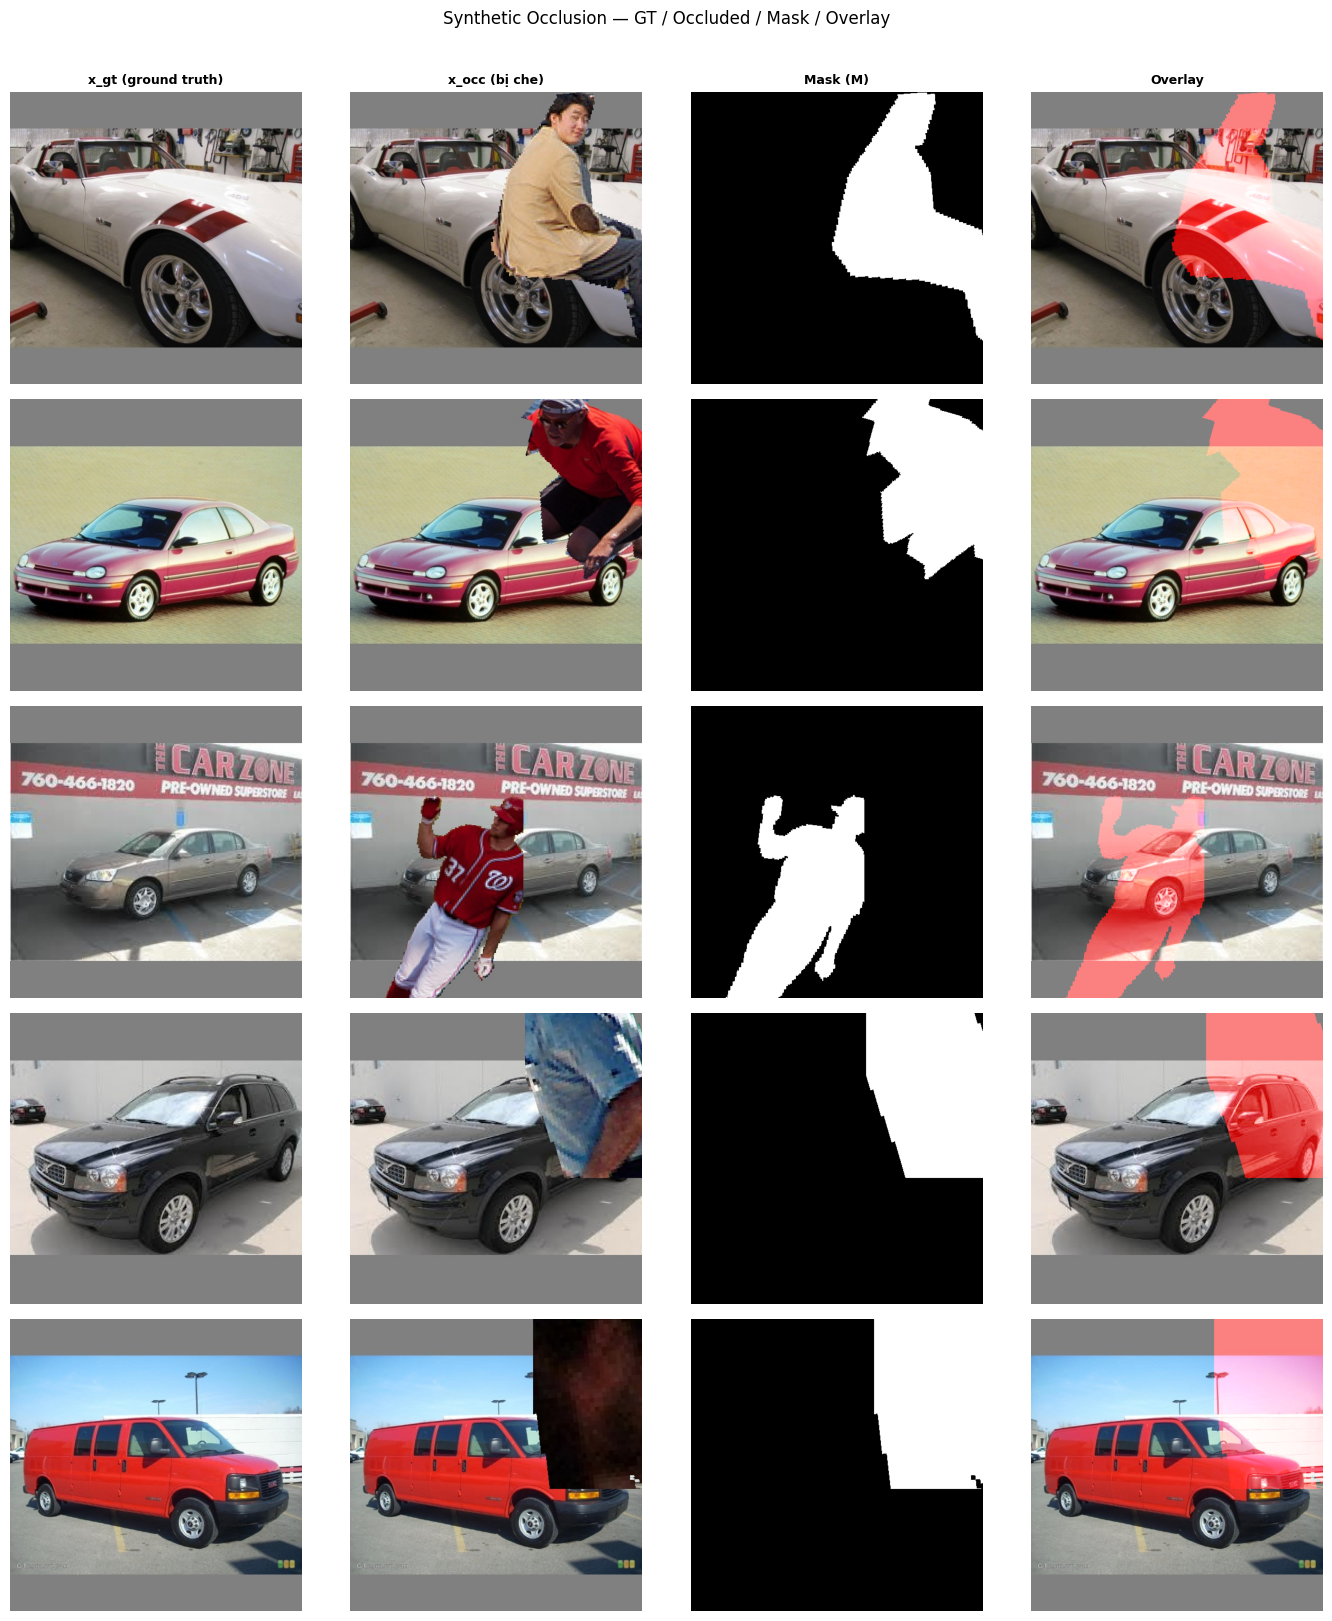

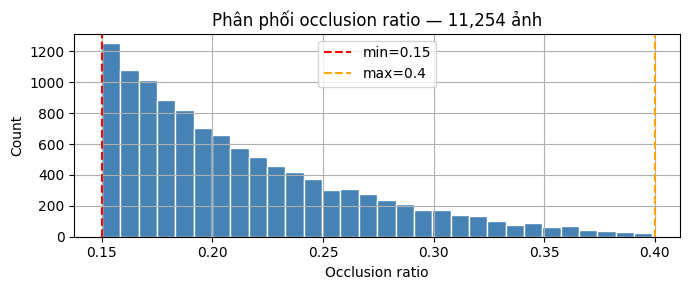

In [8]:
# ─────────────────────────────────────────────
# CELL 9 — Visualization: kiểm tra chất lượng
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

meta_vis = pd.read_csv(SYNTH_META_CSV)
show_n = min(5, len(meta_vis))

if show_n == 0:
    print("Chưa có sample nào trong metadata_synthetic_occ.csv")
else:
    samples = meta_vis.sample(show_n, random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(show_n, 4, figsize=(14, 3.2 * show_n))
    if show_n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["x_gt (ground truth)", "x_occ (bị che)", "Mask (M)", "Overlay"]

    for i, row in samples.iterrows():
        gt   = cv2.cvtColor(cv2.imread(str(GT_DIR   / row["x_gt"])),  cv2.COLOR_BGR2RGB)
        occ  = cv2.cvtColor(cv2.imread(str(OCC_DIR  / row["x_occ"])), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(MASK_DIR / row["mask"]), cv2.IMREAD_GRAYSCALE)

        overlay = gt.copy()
        red_channel = overlay[:, :, 0]
        red_channel[mask > 127] = np.clip(red_channel[mask > 127] * 0.4 + 200, 0, 255)
        overlay[:, :, 0] = red_channel

        for j, (img_data, cmap) in enumerate([(gt, None), (occ, None), (mask, "gray"), (overlay, None)]):
            axes[i, j].imshow(img_data, cmap=cmap)
            if i == 0:
                axes[i, j].set_title(col_titles[j], fontsize=9, fontweight="bold")
            axes[i, j].set_ylabel(f"occ={row.occlusion_ratio:.2f}", fontsize=8)
            axes[i, j].axis("off")

    plt.suptitle("Synthetic Occlusion — GT / Occluded / Mask / Overlay", y=1.01)
    plt.tight_layout()
    plt.show()

    fig2, ax = plt.subplots(figsize=(7, 3))
    meta_vis["occlusion_ratio"].hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.axvline(IOU_MIN, color="red", linestyle="--", label=f"min={IOU_MIN}")
    ax.axvline(IOU_MAX, color="orange", linestyle="--", label=f"max={IOU_MAX}")
    ax.set_xlabel("Occlusion ratio")
    ax.set_ylabel("Count")
    ax.set_title(f"Phân phối occlusion ratio — {len(meta_vis):,} ảnh")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Task 3 — VRAM Check + SD Inpainting Smoke-test

**Mục tiêu:**
- Đo peak VRAM trước/sau khi load model
- Xác nhận `xformers` memory-efficient attention hoạt động
- Chạy 1 pass inpainting thực tế, in kết quả + thời gian inference
- Nếu VRAM không đủ: hướng dẫn fallback (CPU offload / attention slicing)

In [9]:
# ─────────────────────────────────────────────
# CELL 11 — VRAM Baseline (trước khi load model)
# ─────────────────────────────────────────────
import subprocess, time
import torch

def vram_info() -> dict:
    """Trả về dict VRAM info (GB). Chạy được cả khi không có GPU."""
    if not torch.cuda.is_available():
        return {"available": False}
    props   = torch.cuda.get_device_properties(0)
    total   = props.total_memory / 1024**3
    reserved= torch.cuda.memory_reserved(0)  / 1024**3
    alloc   = torch.cuda.memory_allocated(0) / 1024**3
    free    = total - reserved
    return {
        "available"   : True,
        "gpu_name"    : props.name,
        "total_gb"    : round(total,    2),
        "reserved_gb" : round(reserved, 2),
        "allocated_gb": round(alloc,    2),
        "free_gb"     : round(free,     2),
    }


def print_vram(label: str):
    info = vram_info()
    if not info["available"]:
        print(f"[{label}] No CUDA GPU found — running on CPU")
        return
    print(
        f"[{label}] GPU: {info['gpu_name']} | "
        f"Total: {info['total_gb']} GB | "
        f"Alloc: {info['allocated_gb']} GB | "
        f"Free: {info['free_gb']} GB"
    )


print_vram("Baseline (trước load model)")

# nvidia-smi snapshot
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
         "--format=csv,noheader,nounits"],
        stderr=subprocess.DEVNULL
    ).decode().strip()
    print(f"\nnvidia-smi:\n  name | total(MiB) | used(MiB) | free(MiB)")
    for line in smi.splitlines():
        print(f"  {line}")
except FileNotFoundError:
    print("nvidia-smi không có — bỏ qua")

[Baseline (trước load model)] GPU: Tesla T4 | Total: 14.56 GB | Alloc: 0.0 GB | Free: 14.56 GB

nvidia-smi:
  name | total(MiB) | used(MiB) | free(MiB)
  Tesla T4, 15360, 3, 14910
  Tesla T4, 15360, 3, 14910


In [10]:
# ─────────────────────────────────────────────
# CELL 12 — Load SD Inpainting + xFormers check
# ─────────────────────────────────────────────
from diffusers import StableDiffusionInpaintPipeline
import torch

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"

print(f"Đang load pipeline: {SD_MODEL_ID}")
print(f"Device: {DEVICE}  |  dtype: {DTYPE}")

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    SD_MODEL_ID,
    torch_dtype=DTYPE,
    safety_checker=None,     # tắt để giảm VRAM
    requires_safety_checker=False,
)
pipe = pipe.to(DEVICE)

# ── xFormers check ───────────────────────────
xformers_ok = False
try:
    pipe.enable_xformers_memory_efficient_attention()
    xformers_ok = True
    print("xFormers: OK — memory efficient attention enabled")
except Exception as e:
    print(f"xFormers: NOT available ({e})")
    # Fallback: attention slicing — giảm VRAM ~20% nhưng chậm hơn
    pipe.enable_attention_slicing(slice_size="auto")
    print("Fallback: attention slicing enabled")

# VRAM sau khi load model
print_vram("Sau load model")

# Optional: CPU offload nếu VRAM < 8 GB
info = vram_info()
if info.get("available") and info["total_gb"] < 8:
    print("\nVRAM < 8 GB — enable sequential CPU offload để an toàn")
    pipe.enable_sequential_cpu_offload()
    print("CPU offload: enabled")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Đang load pipeline: runwayml/stable-diffusion-inpainting
Device: cuda  |  dtype: torch.float16


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--r

xFormers: OK — memory efficient attention enabled
[Sau load model] GPU: Tesla T4 | Total: 14.56 GB | Alloc: 2.01 GB | Free: 12.5 GB


Input image : (512, 512)  |  occlusion ratio: 0.209
Mask pixels : 54,836 / 262,144 = 20.9%

Đang chạy SD inpainting (20 steps) ...


  0%|          | 0/20 [00:00<?, ?it/s]


Peak VRAM  : 2677 MiB  (2.61 GiB)
Inference  : 4.21s  |  xFormers: True
[Sau inference] GPU: Tesla T4 | Total: 14.56 GB | Alloc: 2.02 GB | Free: 11.67 GB


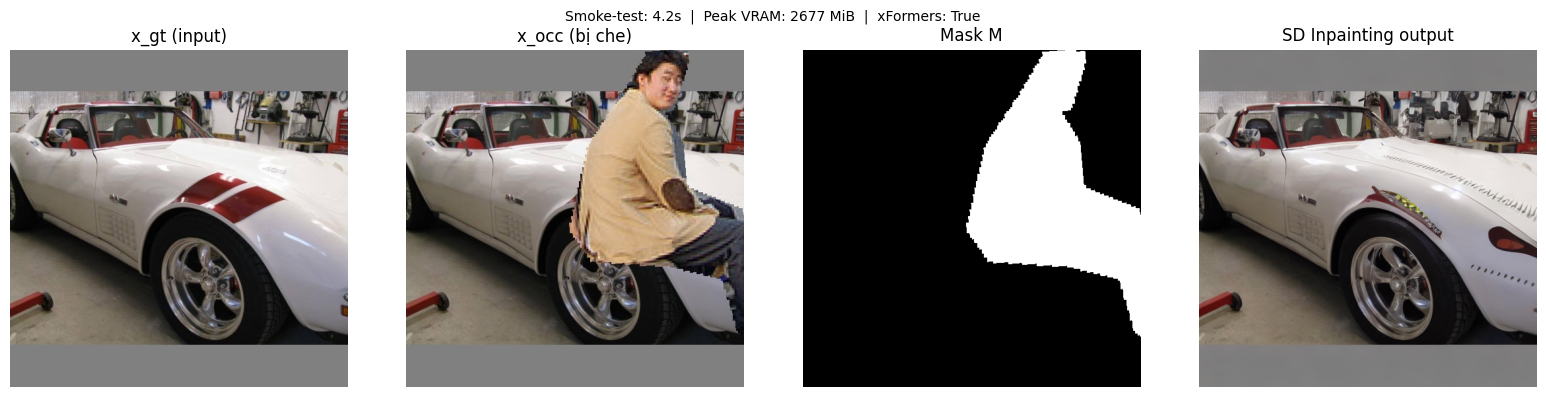


SMOKE-TEST REPORT
  GPU           : Tesla T4
  VRAM total    : 14.56 GiB
  Peak VRAM used: 2.61 GiB
  Headroom      : 11.95 GiB
  ✓  Headroom đủ cho training batch nhỏ
  xFormers      : ✓ enabled
  Inference time: 4.21s / image  (20 steps)


In [11]:
# ─────────────────────────────────────────────
# CELL 13 — SD Inpainting Smoke-test (1 ảnh)
# ─────────────────────────────────────────────
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time

# Lấy 1 sample từ synthetic dataset vừa tạo
meta_vis = pd.read_csv(SYNTH_META_CSV)
sample   = meta_vis.sample(1, random_state=SEED).iloc[0]

s_gt   = sample["x_gt"]
s_occ  = sample["x_occ"]
s_mask = sample["mask"]
s_ratio = sample["occlusion_ratio"]

img_pil  = Image.open(GT_DIR   / s_gt  ).convert("RGB").resize((512, 512))
mask_pil = Image.open(MASK_DIR / s_mask).convert("L").resize((512, 512))

# Đảm bảo mask binary: 255 = vùng inpaint (che khuất)
mask_arr = np.array(mask_pil)
mask_arr = (mask_arr > 127).astype(np.uint8) * 255
mask_pil = Image.fromarray(mask_arr)


print(f"Input image : {img_pil.size}  |  occlusion ratio: {sample.occlusion_ratio:.3f}")
print(f"Mask pixels : {(mask_arr > 0).sum():,} / {512*512:,} = {(mask_arr > 0).mean()*100:.1f}%")

# Reset peak VRAM counter
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

PROMPT = (
    "a car, clean and complete, photorealistic, "
    "no occlusion, same color and texture as surrounding"
)
NEG_PROMPT = "blurry, distorted, extra wheels, extra cars, artifacts"

print("\nĐang chạy SD inpainting (20 steps) ...")
t0 = time.perf_counter()

with torch.inference_mode():
    result = pipe(
        prompt            = PROMPT,
        negative_prompt   = NEG_PROMPT,
        image             = img_pil,
        mask_image        = mask_pil,
        num_inference_steps = 20,
        guidance_scale    = 7.5,
        generator         = torch.Generator(device=DEVICE).manual_seed(SEED),
    ).images[0]

elapsed = time.perf_counter() - t0

# Peak VRAM
if torch.cuda.is_available():
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    print(f"\nPeak VRAM  : {peak_mb:.0f} MiB  ({peak_mb/1024:.2f} GiB)")
else:
    peak_mb = 0
    print("\nPeak VRAM  : N/A (CPU mode)")

print(f"Inference  : {elapsed:.2f}s  |  xFormers: {xformers_ok}")
print_vram("Sau inference")

# ── Visualize ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_pil);                        axes[0].set_title("x_gt (input)")
axes[1].imshow(Image.open(OCC_DIR / sample.x_occ)); axes[1].set_title("x_occ (bị che)")
axes[2].imshow(mask_pil, cmap="gray");          axes[2].set_title("Mask M")
axes[3].imshow(result);                         axes[3].set_title("SD Inpainting output")

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Smoke-test: {elapsed:.1f}s  |  Peak VRAM: {peak_mb:.0f} MiB  |  xFormers: {xformers_ok}",
    fontsize=10,
)
plt.tight_layout()
plt.show()

# ── Summary report ───────────────────────────
print("\n" + "="*55)
print("SMOKE-TEST REPORT")
print("="*55)
info = vram_info()
if info.get("available"):
    print(f"  GPU           : {info['gpu_name']}")
    print(f"  VRAM total    : {info['total_gb']} GiB")
    print(f"  Peak VRAM used: {peak_mb/1024:.2f} GiB")
    headroom = info['total_gb'] - peak_mb/1024
    print(f"  Headroom      : {headroom:.2f} GiB")
    if headroom < 1.5:
        print("  ⚠️  Headroom thấp — tăng offload hoặc giảm batch size khi train")
    else:
        print("  ✓  Headroom đủ cho training batch nhỏ")
else:
    print("  Running on CPU — inference rất chậm, dùng Kaggle GPU để train")
print(f"  xFormers      : {'✓ enabled' if xformers_ok else '✗ fallback attention slicing'}")
print(f"  Inference time: {elapsed:.2f}s / image  (20 steps)")
print("="*55)